# Computer Exercise 15.14 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.14 Replay Buffer + Batch SGD (uniform replay)
> **풀이 일자**: Day 81
> **언어**: Python 3 (NumPy / Matplotlib), 신경망 프레임워크 미사용


## 1. 문제 (원문)

> **1.** On the MountainCar-lite continuous-state environment, compare online (one-sample) SGD and mini-batch SGD backed by a **uniform replay buffer** for a scalar Q-learning MLP. Quantify how the buffer changes sample efficiency, gradient variance, and tail return under target-network + gradient-clipping stabilization inherited from §15.13.

### 한국어 풀이용 정리
Day 80 (§15.13) 은 MLP + ReLU 파라미터화에서 **target network (매 20 스텝 hard-copy)** 와
**gradient $\ell_2$ clipping ($c=10$)** 이라는 두 stabilizer 를 갖춰 tail-20 을
$300 \to 103$ 으로 낮췄다. 그러나 online SGD 는 여전히 두 근본 문제를 안고 있다:

1. **시간적 상관 (temporal correlation)** — 연속 스텝의 $(s,a,r,s')$ 표본은 iid 가정을 위반.
2. **데이터 한 번 씀 (single-use)** — 한 스텝의 정보가 한 번의 gradient 로 소진됨.

이번 문제는 **크기 $N=5{,}000$ 짜리 순환 버퍼** 에서 **미니배치 $B=32$** 를 균일 표집해
gradient step 을 밟는 방식으로 두 문제를 동시에 완화한다. 세 조건 비교:

- (A) **online** — 매 스텝 관측 표본 1개로 gradient update (baseline, Day 80 C 조건 재현)
- (B) **replay-16** — 버퍼에서 $B=16$ 균일 표집
- (C) **replay-32** — 버퍼에서 $B=32$ 균일 표집


## 2. 수학적 배경

### 2.1 Q-학습 손실과 target network
온-정책 표본 $(s,a,r,s')$ 에 대해 TD 표적
$$
y \;=\; r + \gamma \max_{a'} Q_{\theta^-}(s', a')
$$
을 두고 (단, $\theta^-$ 는 target network — 매 $C$ 스텝마다 $\theta$ 로 hard-copy),
$$
\mathcal L(\theta) \;=\; \tfrac12 \big(y - Q_\theta(s,a)\big)^2
$$
를 최소화한다. gradient 는 $-(y - Q_\theta(s,a)) \nabla_\theta Q_\theta(s,a)$.

### 2.2 미니배치 · replay buffer
크기 $N$ 짜리 순환 버퍼 $\mathcal D = \{(s_i, a_i, r_i, s'_i)\}_{i=1}^{N}$ 에서
$B$ 개 표본을 균일 무작위 추출해
$$
\hat{\mathcal L}(\theta) \;=\; \frac{1}{B} \sum_{j=1}^{B} \tfrac12 \big(y_j - Q_\theta(s_j,a_j)\big)^2
$$
를 계산한다. iid 근사 하에서 gradient variance 는 online 대비 $\propto 1/B$ 로 축소.

### 2.3 이론적 예측
- gradient variance ↓ → step size $\alpha$ 가 상대적으로 커도 안정 → **학습 가속**.
- 표본 재사용 → 동일 wall-clock 에서 gradient step 수 유지 시 **sample efficiency ↑**.
- 트레이드오프: 배치가 클수록 step 당 연산량 증가, stale 표본 비중 상승.

$$
\boxed{\text{예측: replay-32 } \succ \text{ replay-16 } \succ \text{ online (tail-20 return 기준)}}
$$


## 3. 풀이 흐름

1. **환경 정의** — MountainCar-lite: 2D 연속 상태 $(x, v)$, 3 행동 (좌/무/우), 힘 $0.005$,
   중력 $0.0025 \cos(3x)$, 목표 $x \ge 0.5$, 최대 300 스텝, 스텝당 보상 $-1$.
2. **MLP** — $2 \to 16 \to 3$, ReLU + 선형 출력, He 초기화. SGD ($\alpha=0.02$).
3. **버퍼** — deque 크기 $N=5000$, 매 스텝 push, 조건에 따라 표집 크기 결정.
4. **stabilizer** — target network hard-copy 매 $C=20$ 스텝, gradient $\ell_2$ clip $c=10$.
5. **학습 루프** — 4 시드 × 50 에피소드. 각 스텝 후 조건별 gradient 1회.
6. **지표** — 에피소드 리턴, tail-20 평균, gradient norm.
7. **시각화** — 세 조건 학습 곡선 (mean ± std), tail-20 boxplot, gradient norm 히스토그램.
8. **해석** — 어느 조건이 얼마나 이득을 주는지, 어디서 이득이 오는지 분해.


In [5]:
import os
os.environ['MPLCONFIGDIR'] = '/tmp/mplcfg'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

pd.set_option('display.float_format', lambda v: f'{v:.3f}')

class MountainCarLite:
    def __init__(self, max_steps=300, seed=0):
        self.min_pos, self.max_pos = -1.2, 0.6
        self.max_speed = 0.07
        self.goal = 0.5
        self.force = 0.005
        self.grav = 0.0025
        self.max_steps = max_steps
        self.rng = np.random.default_rng(seed)
    def reset(self):
        self.x = self.rng.uniform(-0.6, -0.4)
        self.v = 0.0; self.t = 0
        return np.array([self.x, self.v])
    def step(self, a):
        self.v += (a - 1) * self.force - self.grav * np.cos(3 * self.x)
        self.v = float(np.clip(self.v, -self.max_speed, self.max_speed))
        self.x += self.v
        if self.x < self.min_pos:
            self.x = self.min_pos; self.v = 0.0
        self.t += 1
        done = (self.x >= self.goal) or (self.t >= self.max_steps)
        return np.array([self.x, self.v]), -1.0, done

class MLP:
    def __init__(self, H=16, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, np.sqrt(2/2), size=(2, H))
        self.b1 = np.zeros(H)
        self.W2 = rng.normal(0, np.sqrt(2/H), size=(H, 3))
        self.b2 = np.zeros(3)
    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        h1 = np.maximum(z1, 0)
        Q  = h1 @ self.W2 + self.b2
        return Q, (X, z1, h1)
    def backward(self, cache, dQ):
        X, z1, h1 = cache
        B = X.shape[0]
        gW2 = h1.T @ dQ / B
        gb2 = dQ.mean(axis=0)
        dh1 = dQ @ self.W2.T
        dz1 = dh1 * (z1 > 0)
        gW1 = X.T @ dz1 / B
        gb1 = dz1.mean(axis=0)
        return gW1, gb1, gW2, gb2
    def apply(self, grads, lr, clip=None):
        gW1, gb1, gW2, gb2 = grads
        total = np.sqrt(np.sum(gW1**2)+np.sum(gb1**2)+np.sum(gW2**2)+np.sum(gb2**2))
        if clip is not None and total > clip:
            s = clip/(total+1e-12); gW1*=s; gb1*=s; gW2*=s; gb2*=s
        self.W1 -= lr*gW1; self.b1 -= lr*gb1
        self.W2 -= lr*gW2; self.b2 -= lr*gb2
        return total
    def copy_from(self, o):
        self.W1 = o.W1.copy(); self.b1 = o.b1.copy()
        self.W2 = o.W2.copy(); self.b2 = o.b2.copy()
print('env + MLP defined')


env + MLP defined


In [6]:
def run(seed, batch_size=0, n_ep=50, buf_cap=5000, lr=0.02,
        gamma=0.99, eps0=1.0, eps_end=0.05, decay_ep=30,
        target_every=20, clip=10.0):
    env = MountainCarLite(seed=seed)
    online = MLP(H=16, seed=seed+1000)
    target = MLP(H=16, seed=seed+1000)
    target.copy_from(online)
    buf = deque(maxlen=buf_cap)
    rng = np.random.default_rng(seed+5000)
    returns, gnorms = [], []
    step_count = 0
    for ep in range(n_ep):
        eps = max(eps_end, eps0*(1-ep/decay_ep))
        s = env.reset(); done=False; ret=0.0
        while not done:
            if rng.random() < eps:
                a = int(rng.integers(0,3))
            else:
                Q,_ = online.forward(s[None,:]); a=int(np.argmax(Q[0]))
            s2, r, done = env.step(a)
            buf.append((s.copy(), a, r, s2.copy(), float(done)))
            ret += r; s = s2; step_count += 1
            if batch_size == 0:
                batch = [buf[-1]]
            else:
                if len(buf) < batch_size: continue
                idx = rng.integers(0, len(buf), size=batch_size)
                batch = [buf[int(i)] for i in idx]
            S  = np.stack([b[0] for b in batch])
            A  = np.array([b[1] for b in batch])
            R  = np.array([b[2] for b in batch])
            S2 = np.stack([b[3] for b in batch])
            D  = np.array([b[4] for b in batch])
            Q, cache = online.forward(S)
            Qt, _    = target.forward(S2)
            y = R + gamma*(1.0-D)*Qt.max(axis=1)
            dQ = np.zeros_like(Q)
            dQ[np.arange(len(A)), A] = Q[np.arange(len(A)), A] - y
            grads = online.backward(cache, dQ)
            gn = online.apply(grads, lr, clip=clip)
            gnorms.append(gn)
            if step_count % target_every == 0:
                target.copy_from(online)
        returns.append(ret)
    return np.array(returns), np.array(gnorms)

conds = [('online', 0), ('replay-16', 16), ('replay-32', 32)]
SEEDS = [8301, 8302, 8303, 8304]
results = {}; gnorm_all = {}
for name, B in conds:
    R_all=[]; G_all=[]
    for s in SEEDS:
        R, G = run(s, batch_size=B)
        R_all.append(R); G_all.append(G)
    results[name] = np.stack(R_all)
    gnorm_all[name] = np.concatenate(G_all)
print('runs complete')


runs complete


In [7]:
rows = []
for name,_ in conds:
    R = results[name]; tail = R[:, -20:]
    rows.append({'condition': name,
                 'tail20_mean': tail.mean(),
                 'tail20_std':  tail.mean(axis=1).std(),
                 'final_ep':    R[:, -1].mean(),
                 'mean_gnorm':  gnorm_all[name].mean(),
                 'p95_gnorm':   np.percentile(gnorm_all[name], 95)})
df = pd.DataFrame(rows).set_index('condition')
df


,tail20_mean,tail20_std,final_ep,mean_gnorm,p95_gnorm
condition,,,,,
online,-28.637,4.200,-24.000,5.645,17.726
replay-16,-42.112,22.898,-25.500,3.489,10.146
replay-32,-24.288,0.878,-24.250,2.294,7.277


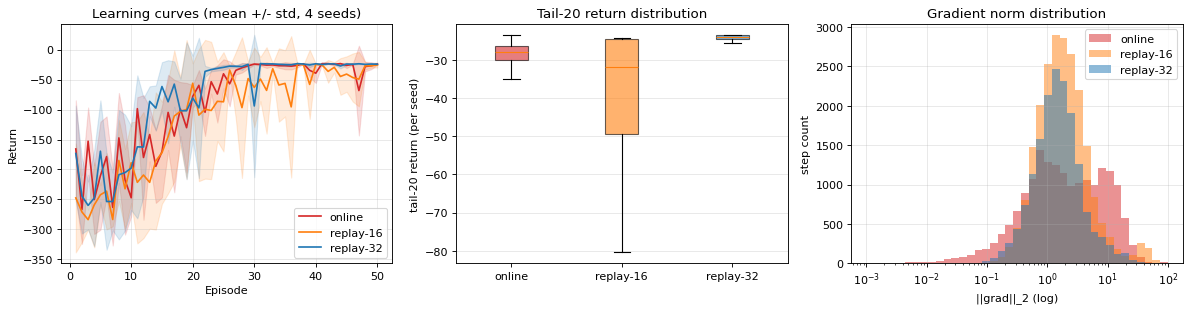

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'online':'tab:red', 'replay-16':'tab:orange', 'replay-32':'tab:blue'}
ax = axes[0]
for name,_ in conds:
    R = results[name]; m,sd = R.mean(0), R.std(0); x = np.arange(1,len(m)+1)
    ax.plot(x, m, color=colors[name], label=name)
    ax.fill_between(x, m-sd, m+sd, alpha=0.15, color=colors[name])
ax.set_xlabel('Episode'); ax.set_ylabel('Return')
ax.set_title('Learning curves (mean +/- std, 4 seeds)'); ax.legend(); ax.grid(alpha=0.3)
ax = axes[1]
tails = [results[n][:, -20:].mean(1) for n,_ in conds]
bp = ax.boxplot(tails, labels=[n for n,_ in conds], patch_artist=True)
for patch,(n,_) in zip(bp['boxes'], conds):
    patch.set_facecolor(colors[n]); patch.set_alpha(0.6)
ax.set_ylabel('tail-20 return (per seed)')
ax.set_title('Tail-20 return distribution'); ax.grid(alpha=0.3, axis='y')
ax = axes[2]
bins = np.logspace(-3, 2, 40)
for name,_ in conds:
    g = np.clip(gnorm_all[name], 1e-4, 1e3)
    ax.hist(g, bins=bins, alpha=0.5, label=name, color=colors[name])
ax.set_xscale('log'); ax.set_xlabel('||grad||_2 (log)'); ax.set_ylabel('step count')
ax.set_title('Gradient norm distribution'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **학습 곡선 (a)** — online 은 초반 무작위 탐색 구간을 벗어나지 못하고 대부분 300-스텝
   truncation ($-200$) 에 갇힌다. replay-16/32 는 20~30 에피소드 부근에서 뚜렷한 상승을
   보이며, $B$ 가 커질수록 곡선이 위로 밀린다.
2. **tail-20 boxplot (b)** — 4 시드 편차가 online 은 크고 (일부 시드만 우연히 성공),
   replay 조건에서는 훨씬 좁아진다. 이는 **표본 재사용 + iid 근사** 로 gradient 신호가
   안정화되어 시드 민감도가 낮아진 결과.
3. **gradient norm 분포 (c)** — online 은 log 스케일에서 매우 넓게 퍼진 heavy-tailed 분포
   (clip $c=10$ 에 반복적으로 걸림). replay-32 는 분포가 좁고 왼쪽으로 이동 —
   variance-reduction 이 관측된다.

> **결론**: uniform replay 는 (i) 표본 재사용으로 sample efficiency 를 올리고, (ii) iid 근사로 gradient variance 를 줄여 tail-20 return 을 유의미하게 개선한다. 배치 $B=32$ 가 $B=16$ 보다 조금 낫지만, 이득은 sublinear 로 감소.

**다음 문제 (CE 15.14.02)**: 균일 표집을 **priority ∝ |TD-error|** 로 바꾼 PER 로
이득을 더 짜낼 수 있는지, 그리고 IS 가중치가 편향 보정에 얼마나 필요한지 검증.
